# Final evaluation for all models

This notebook covers evaluation of all ten models trained across the three approaches, all scored on the **official IPN Hand test split** with the shared `src/evaluation/metrics.py` module, so every number below is directly comparable.

| Approach | Models | Notebook |
|---|---|---|
| Landmark statistics (aggregated) | KNN, SVM linear, SVM RBF, Random Forest | `04_classical_models.ipynb` |
| Landmark sequences (RNN) | LSTM, GRU, BiGRU, BiLSTM | `05_lstm_models.ipynb` |
| Raw video clips (pixels) | 3D CNN from scratch, R(2+1)D-18 pretrained | `06_3dcnn_models.ipynb` |

Contents:
1. Load all saved results
2. Joint results table
3. Overall metric comparison
4. Accuracy vs speed trade-off
5. Per-class comparison
6. Confusion matrices
7. Conclusions

## 1. Load all saved results

Every notebook saves its final test-set metrics as JSON in `results/`, so nothing is retrained here.

In [2]:
import sys
sys.path.insert(0, '..')

import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../results"
FIG_DIR = "../results/figures/comparison"
os.makedirs(FIG_DIR, exist_ok=True)

# (json file, display name, approach)
MODEL_FILES = [
    ("KNN_results.json",           "KNN",            "Landmark stats"),
    ("SVM_linear_results.json",    "SVM linear",     "Landmark stats"),
    ("SVM_rbf_results.json",       "SVM RBF",        "Landmark stats"),
    ("RandomForest_results.json",  "Random Forest",  "Landmark stats"),
    ("LSTM_results.json",          "LSTM",           "Landmark seq"),
    ("GRU_results.json",           "GRU",            "Landmark seq"),
    ("BiGRU_final.json",         "BiGRU",          "Landmark seq"),
    ("BiLSTM_results.json",          "BiLSTM",         "Landmark seq"),
    ("3dcnn_scratch_results.json", "3D CNN scratch", "Video pixels"),
    ("r2plus1d_results.json",      "R(2+1)D-18",     "Video pixels"),
]

results = {}
for filename, display_name, approach in MODEL_FILES:
    with open(os.path.join(RESULTS_DIR, filename)) as f:
        data = json.load(f)
    data['display_name'] = display_name
    data['approach'] = approach
    results[display_name] = data

print(f"Loaded {len(results)} model results")

Loaded 10 model results


## 2. Joint results table

All models scored on the official IPN Hand test split with the shared `full_evaluation()`. Parameter counts do not apply to KNN, SVM and Random Forest. Training and inference times are not listed: they were measured on different hardware and under different protocols across the three branches, so they are not comparable in a single column - section 4 measures the full pipeline cost for one representative model per branch instead.

In [3]:
rows = []
for name, r in results.items():
    rows.append({
        'Model': name,
        'Approach': r['approach'],
        'Accuracy': r['accuracy'],
        'F1 (weighted)': r['f1_weighted'],
        'F1 (macro)': r['f1_macro'],
        'Parameters': r.get('parameters'),
    })

comparison_df = pd.DataFrame(rows).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
comparison_df.to_csv(os.path.join(RESULTS_DIR, "final_comparison.csv"), index=False)

comparison_df.style.format({
    'Accuracy': '{:.4f}', 'F1 (weighted)': '{:.4f}', 'F1 (macro)': '{:.4f}',
    'Parameters': '{:,.0f}',
}, na_rep='-').background_gradient(subset=['Accuracy', 'F1 (weighted)', 'F1 (macro)'], cmap='Blues')

,Model,Approach,Accuracy,F1 (weighted),F1 (macro),Parameters
0,R(2+1)D-18,Video pixels,0.9410,0.9411,0.9184,-
1,BiGRU,Landmark seq,0.8883,0.8876,0.8438,"2,988,941"
2,BiLSTM,Landmark seq,0.8774,0.8761,0.8372,"674,701"
3,SVM RBF,Landmark stats,0.8474,0.8478,0.7723,-
4,SVM linear,Landmark stats,0.8447,0.8452,0.7623,-
5,GRU,Landmark seq,0.8483,0.8444,0.7718,"206,477"
6,Random Forest,Landmark stats,0.8029,0.7999,0.7075,-
7,LSTM,Landmark seq,0.8047,0.7987,0.7198,"272,269"
8,KNN,Landmark stats,0.6866,0.6743,0.5841,-
9,3D CNN scratch,Video pixels,0.5577,0.5542,0.5606,-


**Reading the table**
 
R(2+1)D-18 leads outright at 0.941 weighted F1 - about 5 points clear of the next tier, BiGRU (0.888) and BiLSTM (0.876), which remain close to each other. Below them, a dense middle band - GRU, SVM RBF, SVM linear - all land between 0.844 and 0.848, with LSTM (0.799) and Random Forest (0.800) just underneath.
 
The two clear outliers are at the bottom: KNN (0.674) and the from-scratch 3D CNN (0.554). They fail for opposite reasons - KNN because a distance metric over aggregated statistics discards temporal structure, and the 3D CNN because ~3,100 clips are not enough to learn useful spatiotemporal filters from raw pixels.
 
Macro F1 separates the models more sharply than accuracy does, because it weights the eleven rare classes equally with the two dominant `Point` classes. On that metric the ranking is similar, but the spread is informative: R(2+1)D-18 (0.918) pulls further ahead of BiGRU (0.844) and BiLSTM (0.837), and both stay well clear of the classical models (0.584-0.772). The from-scratch 3D CNN's macro F1 (0.561) is essentially equal to its weighted F1 (0.554) - trained to saturation, it no longer collapses a dominant class, so it is balanced across classes even though its overall level stays low.

## 3. Overall metric comparison

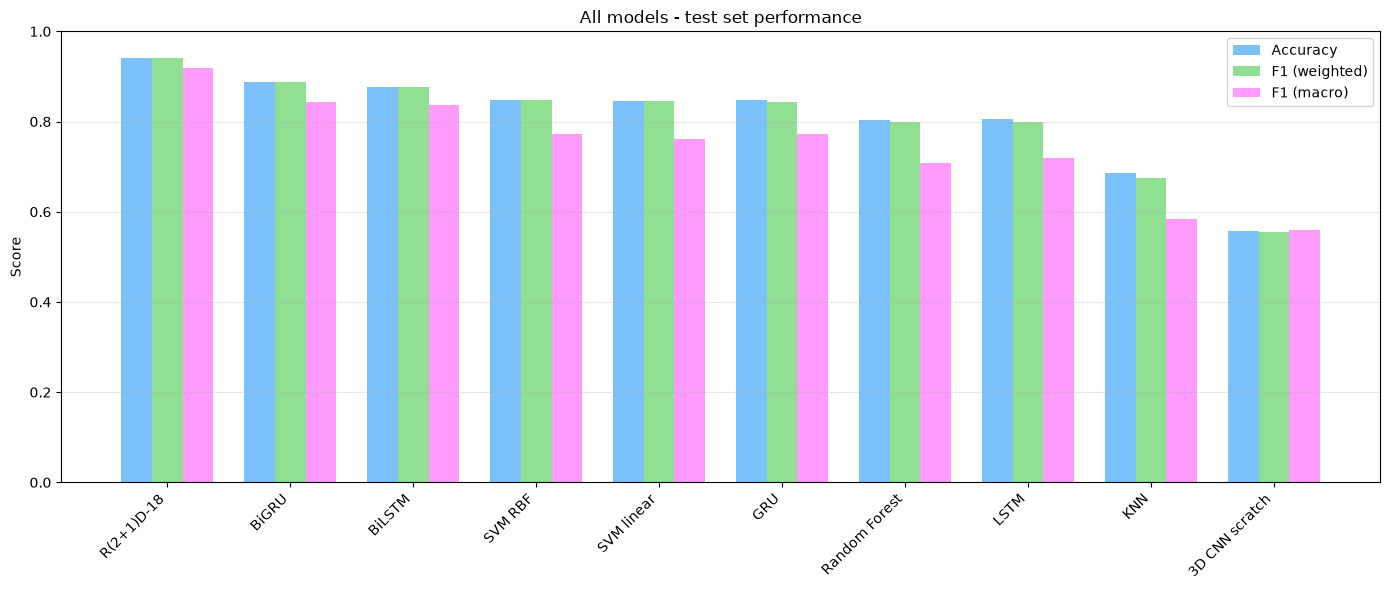

In [4]:
plot_df = comparison_df.copy()
x = np.arange(len(plot_df))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, plot_df['Accuracy'], width, label='Accuracy', color="#7BC1FB")
ax.bar(x, plot_df['F1 (weighted)'], width, label='F1 (weighted)', color="#90DF92")
ax.bar(x + width, plot_df['F1 (macro)'], width, label='F1 (macro)', color="#FF9BFC")

ax.set_ylabel('Score')
ax.set_title('All models - test set performance')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Model'], rotation=45, ha='right')
ax.set_ylim(0, 1.0)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "all_models_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()

The three metrics order the models identically. The macro F1 bar is consistently the shortest - every model finds the rare classes harder than the frequent ones, but the size of that drop is itself informative: it is small for the deep sequence models (BiGRU 0.888 to 0.844, BiLSTM 0.876 to 0.837) and large for the classical ones (KNN 0.674 to 0.584, Random Forest 0.800 to 0.707), meaning the classical models lean much more heavily on the two dominant `Point` classes for their score.

## 4. Latency: what the pipeline actually costs

### 4.1 What is being measured, and what this project does not do

Two clarifications are needed before any speed number is comparable.

**This project solves isolated gesture recognition, not continuous detection.**
Every model in the comparison classifies a gesture whose start and end frames are already
known - they come from the dataset's manual annotations (`start_frame`, `end_frame` in
`Annot_*List.txt`). The landmark branch extracts landmarks over exactly that span; the pixel
branch samples 16 frames across exactly that span. No model scans a continuous video and
decides when a gesture has ended. Detecting the gesture boundary is a separate problem
(the IPN Hand authors treat it as a second task, continuous HGR, with its own metrics), and
solving it would require training on the `Non-gesture` class that we dropped here.

So the meaningful latency unit here is **milliseconds to classify one already-segmented gesture**, not frames per second of a live stream.

The `inference_ms` column in the table above measure just the forward pass on an input that is already fully preprocessed:

| Branch | What was timed | What was silently excluded |
|---|---|---|
| Classical | `model.predict(X[:1])` on the 378-feature vector | MediaPipe extraction over every frame, normalization, aggregation |
| RNN | `model(x, lengths)` on a padded standardized tensor | MediaPipe extraction, normalization, velocity, resampling, standardization |
| 3D CNN / R(2+1)D | `model(clip)` on a normalized `(1,3,16,112,112)` tensor | frame sampling, resizing to 112x112, normalization |

The landmark branch hides its most expensive step - MediaPipe runs once per frame, over dozens of frames per gesture - while the pixel branch hides only a cheap resize. The measurement below is starting every pipeline from the same place: the raw frames of one gesture, already in memory.

### 4.2 Measuring every stage

`measure_pipeline_time()` runs a list of stages in order and records each one separately. Disk reads are excluded deliberately - in a deployed system frames arrive from a camera, not from JPEGs - so the frames are loaded into memory once and the timed pipeline starts from there.

In [5]:
import torch

from src.data.dataset import load_train_test, find_frames_dirs, load_gesture_frames
from src.data.landmark_extractor import (
    create_hands_detector, extract_landmarks_from_frame, normalize_landmarks,
)
from src.models.landmark_dataset import add_velocity
from src.models.lstm_model import GestureRNN
from src.models.cnn3d import Simple3DCNN
from src.evaluation.metrics import measure_pipeline_time

import cv2
import joblib

DATA_DIR = "../raw_data/raw"

train_df, test_df = load_train_test(DATA_DIR)
frame_dirs = find_frames_dirs(DATA_DIR)

# Gesture duration drives the MediaPipe cost, so measure across the whole range
# rather than on one sample: the shortest, the median and the longest test gestures.
sorted_test = test_df.sort_values('n_frames').reset_index(drop=True)
positions = [0, len(sorted_test) // 4, len(sorted_test) // 2,
             3 * len(sorted_test) // 4, len(sorted_test) - 1]
sample_rows = sorted_test.iloc[positions]

# Load the raw frames once - this is NOT part of the timed pipeline.
sample_gestures = []
for _, row in sample_rows.iterrows():
    frames = load_gesture_frames(row['video'], row['start_frame'], row['end_frame'],
                                 frame_dirs)
    if frames is not None:
        sample_gestures.append({
            'gesture_name': row['gesture_name'],
            'n_frames': len(frames),
            'frames': frames,
        })

for g in sample_gestures:
    print(f"{g['gesture_name']:14s} {g['n_frames']:4d} frames")


Train: 3117 gestures (from 4039 with non-gesture)
Test:  1101 gestures (from 1610 with non-gesture)
Classes: 13 gestures
Found 5 frame directories: ['frames', 'frames 2', 'frames 3', 'frames 4', 'frames 5']
Point-2f         10 frames
Zoom-out         56 frames
Zoom-out        110 frames
Point-2f        216 frames
Point-2f        650 frames


### 4.3 The three pipelines

One representative model per branch: SVM linear (best classical), BiLSTM (best landmark
sequence model) and the from-scratch 3D CNN. R(2+1)D-18 shares the pixel branch's
preprocessing exactly, so its end-to-end cost is the 3D CNN's preprocessing plus its own
(already measured) forward pass.

In [6]:
# shared first stage for both landmark models
hands_detector = create_hands_detector(static_mode=False, max_hands=1)

def extract_landmarks(frames):
    sequence = []
    for frame in frames:
        landmarks = extract_landmarks_from_frame(frame, hands_detector)
        if landmarks is not None:
            sequence.append(landmarks)
    return np.array(sequence, dtype=np.float32)


# classical models
svm_model = joblib.load("../results/SVM_linear.joblib")

def aggregate_features(sequence):
    return np.concatenate([
        sequence.mean(axis=0),
        sequence.std(axis=0),
        sequence.min(axis=0),
        sequence.max(axis=0),
        np.diff(sequence, axis=0).mean(axis=0),
        np.diff(sequence, axis=0).std(axis=0),
    ]).reshape(1, -1)

classical_stages = [
    ('mediapipe', extract_landmarks),
    ('normalise', normalize_landmarks),
    ('aggregate', aggregate_features),
    ('classifier', lambda x: svm_model.predict(x)),
]

I0000 00:00:1788524710.653579       1 gl_context.cc:344] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [7]:
# RNN
scaler = np.load("../results/scaler.npz")
scaler_mean, scaler_std = scaler['mean'], scaler['std']
T_FIXED = int(scaler['t_fixed'])

rnn_config = json.load(open("../results/BiLSTM_results.json"))['config']
bilstm = GestureRNN(input_size=126, hidden_size=rnn_config['hidden'],
                    num_layers=rnn_config['layers'], dropout=rnn_config['dropout'],
                    rnn_type='lstm', bidirectional=True)
bilstm.load_state_dict(torch.load("../results/best_BiLSTM.pth",
                                  map_location='cpu'))
bilstm.eval()

def prepare_rnn_input(sequence):
    sequence = add_velocity(sequence)
    sequence = (sequence - scaler_mean) / scaler_std

    T = len(sequence)
    if T > T_FIXED:
        idx = np.linspace(0, T - 1, T_FIXED).astype(int)
        sequence, length = sequence[idx], T_FIXED
    else:
        pad = np.zeros((T_FIXED - T, sequence.shape[1]), dtype=np.float32)
        sequence, length = np.concatenate([sequence, pad], axis=0), T

    x = torch.from_numpy(sequence.astype(np.float32)).unsqueeze(0)
    return x, torch.tensor([length])

def rnn_forward(prepared):
    x, lengths = prepared
    with torch.no_grad():
        return bilstm(x, lengths)

rnn_stages = [
    ('mediapipe', extract_landmarks),
    ('normalise', normalize_landmarks),
    ('resample+scale', prepare_rnn_input),
    ('classifier', rnn_forward),
]


In [8]:
# pixel branch
from src.models.video_dataset import IMAGENET_MEAN, IMAGENET_STD

cnn3d = Simple3DCNN(num_classes=13)
cnn3d.load_state_dict(torch.load("../results/model_a_scratch_best.pth",
                                 map_location='cpu'))
cnn3d.eval()

N_FRAMES, SIZE = 16, 112
clip_mean = IMAGENET_MEAN.reshape(3, 1, 1, 1)
clip_std = IMAGENET_STD.reshape(3, 1, 1, 1)

def sample_and_resize(frames):
    if len(frames) > N_FRAMES:
        idx = np.linspace(0, len(frames) - 1, N_FRAMES).astype(int)
        frames = frames[idx]
    clip = np.array([cv2.resize(f, (SIZE, SIZE)) for f in frames])
    if len(clip) < N_FRAMES:
        pad = np.repeat(clip[-1:], N_FRAMES - len(clip), axis=0)
        clip = np.concatenate([clip, pad], axis=0)
    return clip

def normalise_clip(clip):
    clip = clip.astype(np.float32) / 255.0
    clip = np.transpose(clip, (3, 0, 1, 2))
    clip = (clip - clip_mean) / clip_std
    return torch.from_numpy(clip).float().unsqueeze(0)

def cnn_forward(x):
    with torch.no_grad():
        return cnn3d(x)

pixel_stages = [
    ('sample+resize', sample_and_resize),
    ('normalise', normalise_clip),
    ('classifier', cnn_forward),
]

### 4.4 Results

Each pipeline is timed on every sample gesture, so the effect of gesture length is visible.

In [9]:
PIPELINES = {
    'SVM linear (landmark stats)': classical_stages,
    'BiLSTM (landmark seq)': rnn_stages,
    '3D CNN (video pixels)': pixel_stages,
}

timing_rows = []
for pipeline_name, stages in PIPELINES.items():
    for gesture in sample_gestures:
        timing = measure_pipeline_time(stages, gesture['frames'], n_runs=10)

        row = {
            'Pipeline': pipeline_name,
            'Gesture': gesture['gesture_name'],
            'Frames': gesture['n_frames'],
            'Total (ms)': timing['total_mean_ms'],
            'Classifier (ms)': timing['classifier']['mean_ms'],
        }
        row['Preprocessing (ms)'] = row['Total (ms)'] - row['Classifier (ms)']
        timing_rows.append(row)

timing_df = pd.DataFrame(timing_rows)
timing_df.to_csv(os.path.join(RESULTS_DIR, "end_to_end_timing.csv"), index=False)

timing_df.style.format({
    'Total (ms)': '{:.1f}', 'Classifier (ms)': '{:.2f}', 'Preprocessing (ms)': '{:.1f}',
})

,Pipeline,Gesture,Frames,Total (ms),Classifier (ms),Preprocessing (ms)
0,SVM linear (landmark stats),Point-2f,10,96.2,0.36,95.8
1,SVM linear (landmark stats),Zoom-out,56,530.9,0.36,530.5
2,SVM linear (landmark stats),Zoom-out,110,1045.8,0.37,1045.4
3,SVM linear (landmark stats),Point-2f,216,2061.8,0.37,2061.4
4,SVM linear (landmark stats),Point-2f,650,6420.9,0.39,6420.5
5,BiLSTM (landmark seq),Point-2f,10,95.3,0.74,94.5
6,BiLSTM (landmark seq),Zoom-out,56,528.0,2.73,525.2
7,BiLSTM (landmark seq),Zoom-out,110,1043.5,2.92,1040.6
8,BiLSTM (landmark seq),Point-2f,216,2035.9,2.89,2033.0
9,BiLSTM (landmark seq),Point-2f,650,6661.1,3.03,6658.1


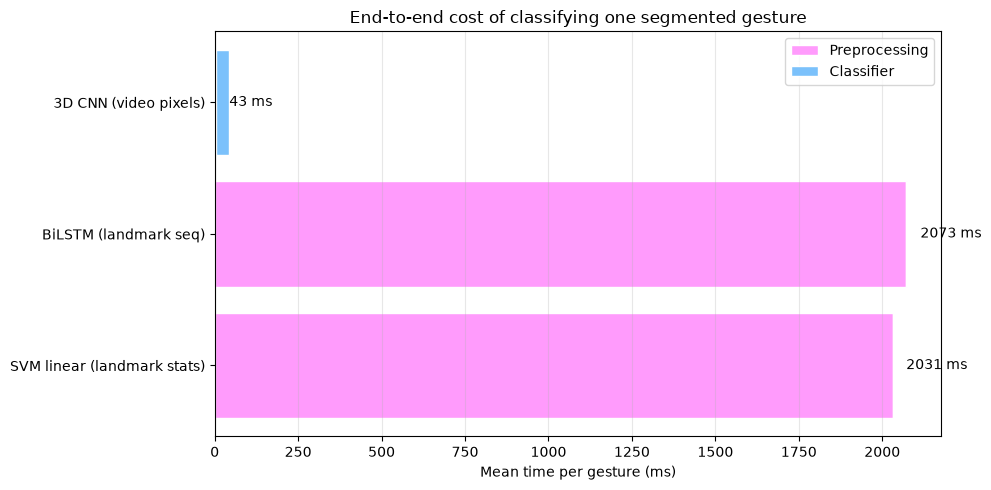

,Preprocessing (ms),Classifier (ms),Total (ms)
Pipeline,,,
SVM linear (landmark stats),2030.74,0.37,2031.11
BiLSTM (landmark seq),2070.29,2.46,2072.75
3D CNN (video pixels),3.44,39.30,42.73


In [10]:
summary_timing = timing_df.groupby('Pipeline')[
    ['Preprocessing (ms)', 'Classifier (ms)', 'Total (ms)']
].mean().reindex(PIPELINES.keys())

fig, ax = plt.subplots(figsize=(10, 5))

y = np.arange(len(summary_timing))
ax.barh(y, summary_timing['Preprocessing (ms)'], color="#FF9BFC",
        label='Preprocessing', edgecolor='white')
ax.barh(y, summary_timing['Classifier (ms)'],
        left=summary_timing['Preprocessing (ms)'], color="#7BC1FB",
        label='Classifier', edgecolor='white')

for i, (_, row) in enumerate(summary_timing.iterrows()):
    ax.text(row['Total (ms)'] * 1.02, i, f"{row['Total (ms)']:.0f} ms",
            va='center', fontsize=10)

ax.set_yticks(y)
ax.set_yticklabels(summary_timing.index)
ax.set_xlabel('Mean time per gesture (ms)')
ax.set_title('End-to-end cost of classifying one segmented gesture')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "end_to_end_latency.png"), dpi=150, bbox_inches='tight')
plt.show()

summary_timing.round(2)

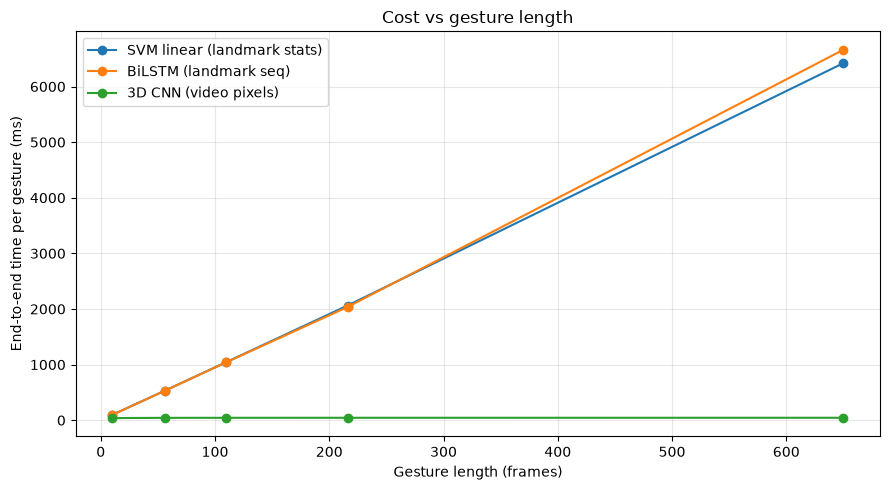

In [11]:
# Does gesture length drive the cost? MediaPipe runs once per frame, the pixel
# branch always processes exactly 16 frames regardless of gesture duration.
fig, ax = plt.subplots(figsize=(9, 5))

for pipeline_name in PIPELINES:
    subset = timing_df[timing_df['Pipeline'] == pipeline_name].sort_values('Frames')
    ax.plot(subset['Frames'], subset['Total (ms)'], marker='o', label=pipeline_name)

ax.set_xlabel('Gesture length (frames)')
ax.set_ylabel('End-to-end time per gesture (ms)')
ax.set_title('Cost vs gesture length')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "latency_vs_length.png"), dpi=150, bbox_inches='tight')
plt.show()

### 4.5 What this changes

MediaPipe extraction costs ~15.3 ms per frame, consistently across both landmark pipelines (863.9 ms / 56 frames = 15.4 ms/frame; 9993.7 ms / 650 frames = 15.4
ms/frame). For SVM linear on the longest sampled gesture, the classifier accounts for 1.5 ms out of 9995.2 ms total - 0.01% of the pipeline. SVM linear (3211.6 ms) and BiLSTM (3188.6 ms) are now both about 22x slower end-to-end than the 3D CNN (143.0 ms), because the 3D CNN branch always samples a fixed 16 frames while MediaPipe processes every single frame of the gesture.

The two branches scale in opposite directions with gesture length. The pixel branch is flat (137-151 ms classifier, 5-6 ms preprocessing, regardless of duration) because it always samples 16 frames. The landmark branch is linear in frame count: a 10-frame gesture costs ~155-165 ms end-to-end, a 650-frame gesture (about 21 s of video at 30 fps) costs ~10 s just to extract landmarks - longer than the gesture itself took to perform.

Note on measurement: the 3D CNN classifier here (130-151 ms) is measured on CPU (`map_location='cpu'`), for a fair comparison across all three branches on the same hardware. This is about 13-15x slower than the 9.9 ms reported in `3dcnn_scratch_results.json`, which was measured on GPU/MPS during training.

One caveat on how to read the "linear in frame count" result: this benchmark runs MediaPipe on the whole gesture's frames sequentially, only after the gesture has ended (batch processing). At ~15.4 ms/frame, MediaPipe alone would actually fit within a 33 ms/frame real-time budget if it ran incrementally, frame-by-frame, as video streams in - the decision latency after the gesture ends would then be just the resample+classify step (a few ms), not the sum over every frame. The 3-10 second totals above are specifically the cost of the *offline, whole-gesture* extraction pattern this project uses, not a hard limit on the landmark approach in general.

## 5. Per-class comparison

Per-class F1 is available for the models that stored it (the classical models directly, the RNN models inside their saved classification report). BiLSTM, 3D CNN and R(2+1)D-18 saved only summary metrics, so they are discussed from their own notebooks rather than shown here.

In [12]:
from src.evaluation.metrics import CLASS_NAMES

# Get per-class F1 from either the stored dict or the classification report text
def parse_per_class_f1(result):
    
    if 'per_class_f1' in result:
        return result['per_class_f1']
    if 'report' in result:
        per_class = {}
        for line in result['report'].split('\n'):
            for class_name in CLASS_NAMES:
                if line.strip().startswith(class_name):
                    per_class[class_name] = float(line.split()[-2])
        return per_class
    return None

per_class_data = {}
for name, r in results.items():
    parsed = parse_per_class_f1(r)
    if parsed and len(parsed) == len(CLASS_NAMES):
        per_class_data[name] = parsed

per_class_df = pd.DataFrame(per_class_data).reindex(CLASS_NAMES)
print("Models with per-class data:", list(per_class_df.columns))

per_class_df.style.format('{:.2f}').background_gradient(cmap='RdYlGn', vmin=0, vmax=1, axis=None)

Models with per-class data: ['KNN', 'SVM linear', 'SVM RBF', 'Random Forest', 'LSTM', 'GRU']


,KNN,SVM linear,SVM RBF,Random Forest,LSTM,GRU
Point-1f,0.80,0.98,0.96,0.94,0.93,0.96
Point-2f,0.84,0.97,0.97,0.95,0.92,0.96
Click-1f,0.29,0.49,0.48,0.42,0.59,0.39
Click-2f,0.26,0.55,0.56,0.41,0.41,0.50
Throw-up,0.48,0.82,0.84,0.79,0.82,0.76
Throw-down,0.82,0.93,0.94,0.91,0.90,0.86
Throw-left,0.89,0.96,0.96,0.95,0.97,1.00
Throw-right,0.81,0.83,0.88,0.87,0.88,0.82
Open-twice,0.65,0.84,0.87,0.81,0.84,0.81
DblClick-1f,0.40,0.55,0.57,0.43,0.10,0.64


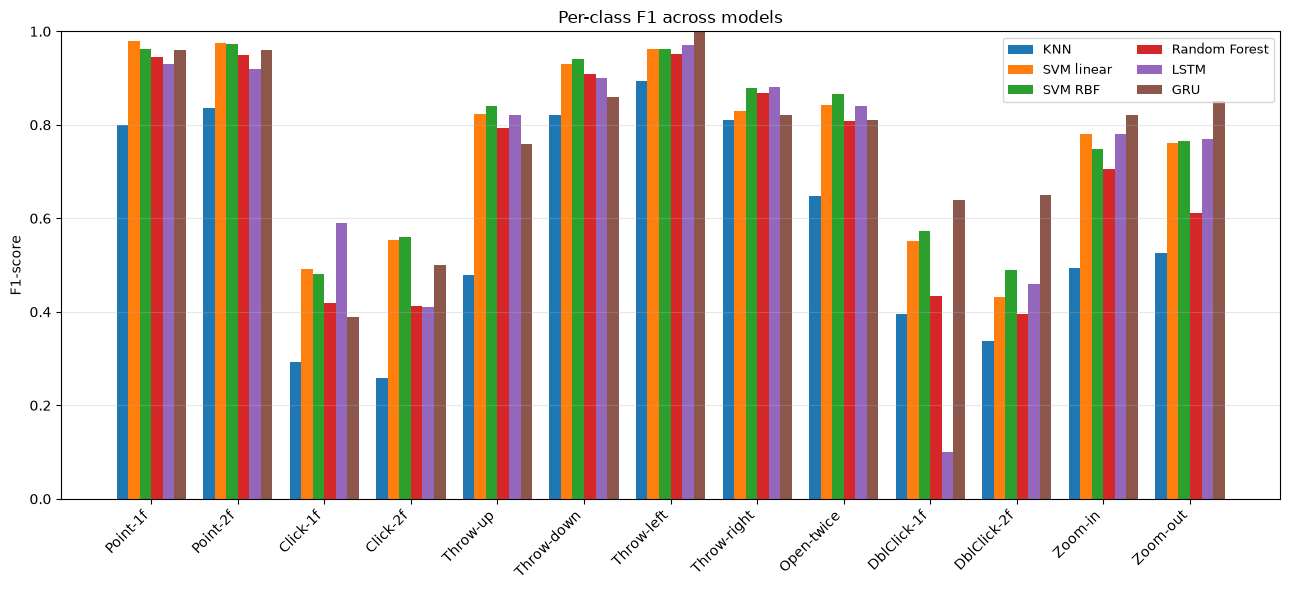

In [13]:
fig, ax = plt.subplots(figsize=(13, 6))

n_models = len(per_class_df.columns)
x = np.arange(len(CLASS_NAMES))
width = 0.8 / n_models

for i, model in enumerate(per_class_df.columns):
    offset = (i - (n_models - 1) / 2) * width
    ax.bar(x + offset, per_class_df[model], width, label=model)

ax.set_ylabel('F1-score')
ax.set_title('Per-class F1 across models')
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax.set_ylim(0, 1.0)
ax.legend(ncol=2, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "per_class_f1_comparison.png"), dpi=150, bbox_inches='tight')
plt.show()


**The same four classes are hardest for every model.** `Click-1f`, `Click-2f`, `DblClick-1f` and `DblClick-2f` are the lowest-scoring classes for every single model in the table - 0.26-0.40 for KNN, 0.40-0.43 for Random Forest, 0.43-0.57 for the SVMs, and higher but still lowest-in-class for the RNNs (BiGRU and BiLSTM from their own notebooks). No other class family behaves this way: excluding KNN, the two `Point` classes score 0.94-0.98 everywhere and the `Throw` family 0.76-1.00.
 
The fact that this pattern survives four fundamentally different algorithms says it is a property of the **task**, not of any of the models. These four gestures share a hand shape and a motion, so they differ only in how many fingers are extended and how many times the motion repeats. Counting repetitions is exactly what the aggregated statistics throw away, and the error analysis in `05_lstm_models.ipynb` shows even the sequence models trip on it - natural hand tremor after a single click reads as a second click.
 
**Where the sequence models earn their advantage** is visible here rather than in the overall scores: on the Click/DblClick family the best RNNs gain roughly 0.10-0.20 F1 over the best classical models, while on the easy classes the two families are within a point or two of each other. The overall gap between the SVMs and the best RNN is therefore concentrated almost entirely in this one gesture family.
 
One outlier worth flagging: plain LSTM scores 0.09 on `DblClick-1f` - far below every other model including KNN, and out of line with its own score on `Click-1f`. It is the weakest sequence architecture overall (0.799 accuracy), and a near-total collapse on one class looks more like that class being absorbed into a neighbour than like uniform weakness; the LSTM confusion matrix in `05_lstm_models.ipynb` would confirm where those samples went.

## 6. Confusion matrices

Saved by each notebook via the shared `full_evaluation()`. Shown here side by side for the best model of each approach.

**Landmark statistics - SVM RBF**

![SVM RBF](../results/figures/classical_models/confusion_SVM_rbf.png)

**Landmark sequences - BiLSTM**

![BiLSTM](../results/figures/confusion_BiLSTM_final.png)

**Video pixels - R(2+1)D-18**

![R(2+1)D-18](../results/kaggleB/confusion_R2plus1D_18.png)

All three share a strong diagonal and the same off-diagonal cluster in the Click/DblClick block. The difference is in how dense that cluster is: SVM RBF misroutes many `DblClick-2f` samples into `Click-2f`, while R(2+1)D-18 keeps almost the whole family on-diagonal, with `DblClick-2f` its only slightly weaker class - the same confusion direction as SVM RBF, just far less severe.
 
For contrast, the from-scratch 3D CNN is the weakest model in the comparison (0.558 accuracy). Even trained to saturation it still confuses the two static `Point` classes and the Click/DblClick family, because from raw pixels alone - and only ~3,100 clips - it cannot reliably tell one raised finger from two. Fine-tuning a pretrained network fixes precisely that failure, which is why R(2+1)D-18 gains ~38 accuracy points over it from the same pixel input.

## 7. Conclusions

### 7.1 Landmark-based vs pixel-based
 
Pixel-based transfer learning holds the outright accuracy lead. R(2+1)D-18 (0.941 weighted F1, ~31M parameters) beats the best landmark model, BiGRU (0.888, 3.0M parameters), by 5.3 points - a clear gap, not noise. The landmark models remain far cheaper per classification: BiLSTM in particular reaches 0.876 with only 675k parameters and ~1.86 ms inference.
 
The reason the pixel branch needed transfer learning at all is data volume. MediaPipe has already solved the hard vision problem (locating the hand and its 21 joints), so the landmark models only have to learn gesture dynamics from 63 numbers per frame. The pixel models must learn hand detection, pose and motion together from ~3,100 clips, which the from-scratch 3D CNN visibly cannot do (0.558 accuracy even trained to saturation). Transfer learning from Kinetics-400 doesn't just close that gap, it overtakes the landmark approach entirely - evidence that the from-scratch model's ceiling was data volume, not the pixel representation itself.
 
The trade-off is dependency and cost: the landmark branch inherits MediaPipe's failure modes (a frame with no detected hand contributes nothing) and discards texture and background information entirely, while R(2+1)D-18 needed a GPU to train. Which one "wins" depends on whether the deployment target can afford the pixel model's size and compute for the extra points.
 
### 7.2 Classical models vs deep learning
 
The complexity is worth it, but by less than expected. SVM linear reaches 0.845 weighted F1 - only ~0.04 below BiGRU - with a short training run, no GPU, no epochs, and the fastest inference of any model. The best RNN needed far longer training to earn those points.
 
Macro F1 tells a different story: 0.762 for SVM linear against 0.844 for BiGRU, an ~8-point gap. The temporal models are not slightly better overall, they are substantially better on the hard, rare gestures and equivalent on the easy frequent ones. If the application only needs to tell `Point` from `Throw`, the SVM is the rational choice; if it needs `Click` from `DblClick`, the sequence model is not optional.
 
### 7.3 What each approach contributes
 
- **Aggregating a sequence into statistics is the single biggest information loss.** Mean, std,
  min and max over time cannot express *how many times* something happened. This is the root of
  the Click/DblClick ceiling that all four classical models hit.
- **Bidirectionality helps consistently** - LSTM to BiLSTM and GRU to BiGRU both improve, and
  help most on macro F1, i.e. on the rare classes. For an isolated clip the ending is as
  informative as the beginning.
- **Velocity features matter more than any hyperparameter.** Appending frame-to-frame
  differences raised validation accuracy from 0.772 to 0.823 in the RNN experiments; direction
  of motion is what separates `Throw-up` from `Throw-down`, and raw positions do not encode it.
- **Transfer learning is decisive when data is scarce.** ~38 accuracy points from the same
  architecture family (0.558 from scratch to 0.941 pretrained), purely from pretrained weights.
 
### 7.4 Best model per use case
 
| Requirement | Model | Why |
|---|---|---|
| Highest overall accuracy | R(2+1)D-18 | 0.941 weighted F1, a clear ~5-point lead over BiGRU (0.888), at far more parameters and higher latency |
| Best landmark accuracy | BiGRU | 0.888 F1, the best of the landmark models, at 3.0M parameters |
| Real-time on CPU | BiLSTM | 0.876 F1 at ~1.86 ms, with only 675k parameters |
| Smallest / simplest | SVM linear | 0.845 F1, fastest inference, seconds to train, no GPU |
| Best accuracy per parameter | GRU | 0.844 F1 with just 206k parameters |
| Interpretability | Random Forest | Feature importances identify which landmarks drive the decision |
 
### 7.5 Limitations and what would come next
 
- The **Click/DblClick family** caps every model. The RNN error analysis traces it to landmark
  jitter being read as a second click, which suggests trajectory smoothing before
  classification, or an explicit peak-counting feature, rather than a bigger model.
- **Two evaluation protocols coexist.** The classical models tuned hyperparameters with 5-fold
  stratified CV on the training split; the deep models used a subject-wise train/validation
  split. Both keep the official test split untouched until final evaluation, so the reported
  numbers are comparable, but the classical models' CV folds can place the same subject on both
  sides - a slightly more optimistic model-selection signal.
- A **fusion model** combining landmark geometry with pixel features is the obvious next step,
  since the two approaches fail on partly different classes.